In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = 128

def load_data(img_dir, mask_dir):
    images, masks = [], []
    for img_name in sorted(os.listdir(img_dir)):
        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name.replace(".png", "_mask.png"))
        if os.path.exists(mask_path):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
            images.append(img[..., np.newaxis])
            masks.append(mask[..., np.newaxis])
    return np.array(images), np.array(masks)

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- Load Data ---
malignant_imgs, malignant_masks = load_data(
    "/content/drive/MyDrive/Breast Cancer Dataset/Image melignant",
    "/content/drive/MyDrive/Breast Cancer Dataset/Mask melignant"
)
norm_imgs, norm_masks = load_data(
    "/content/drive/MyDrive/Breast Cancer Dataset/Image normal",
    "/content/drive/MyDrive/Breast Cancer Dataset/Mask normal"
)
full_imgs, full_masks = load_data(
    "/content/drive/MyDrive/Breast Cancer Dataset/Images",
    "/content/drive/MyDrive/Breast Cancer Dataset/Mask"
)
benign_imgs, benign_masks = load_data(
    "/content/drive/MyDrive/Breast Cancer Dataset/Images benign",
    "/content/drive/MyDrive/Breast Cancer Dataset/Mask benign"
)

# --- Combine all data ---
X = np.concatenate([malignant_imgs, norm_imgs, full_imgs, benign_imgs], axis=0)
y = np.concatenate([malignant_masks, norm_masks, full_masks, benign_masks], axis=0)

# --- Split into Train / Validation ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

print("Before augmentation:")
print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)

# --- Augmentation: Rotate 90°
def rotate_images(images, masks):
    aug_imgs, aug_masks = [], []
    for img, mask in zip(images, masks):
        for k in [1]:  # 90
            aug_imgs.append(np.rot90(img, k))
            aug_masks.append(np.rot90(mask, k))
    return np.array(aug_imgs), np.array(aug_masks)

rot_imgs, rot_masks = rotate_images(X_train, y_train)

# Merge with original training set
X_train = np.concatenate([X_train, rot_imgs], axis=0)
y_train = np.concatenate([y_train, rot_masks], axis=0)

print("\nAfter augmentation:")
print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)

Before augmentation:
Training data: (1247, 128, 128, 1) (1247, 128, 128, 1)
Validation data: (312, 128, 128, 1) (312, 128, 128, 1)

After augmentation:
Training data: (2494, 128, 128, 1) (2494, 128, 128, 1)
Validation data: (312, 128, 128, 1) (312, 128, 128, 1)


In [4]:
def residual_block(x, filters):

    shortcut = x

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters,3,padding="same")(x)
    x = BatchNormalization()(x)

    shortcut = Conv2D(filters,1,padding="same")(shortcut)

    x = Add()([x,shortcut])
    x = Activation("relu")(x)

    return x

In [5]:
def multi_scale_block(x, filters):

    c1 = Conv2D(filters,3,padding="same",activation="relu")(x)
    c2 = Conv2D(filters,5,padding="same",activation="relu")(x)
    c3 = Conv2D(filters,7,padding="same",activation="relu")(x)
    c4 = Conv2D(filters,3,dilation_rate=2,padding="same",activation="relu")(x)

    x = Concatenate()([c1,c2,c3,c4])

    x = Conv2D(filters,1,padding="same")(x)

    return x

In [6]:
def z_pool(x):

    max_pool = Lambda(lambda z: tf.reduce_max(z,axis=-1,keepdims=True))(x)
    avg_pool = Lambda(lambda z: tf.reduce_mean(z,axis=-1,keepdims=True))(x)

    return Concatenate()([max_pool,avg_pool])

In [7]:
def spatial_attention(x):

    z = z_pool(x)

    z = Conv2D(1,7,padding="same")(z)
    z = Activation("sigmoid")(z)

    return Multiply()([x,z])

In [8]:
def channel_attention(x, ratio=8):

    channels = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)

    dense1 = Dense(channels//ratio,activation="relu")(avg_pool)
    dense2 = Dense(channels,activation="sigmoid")(dense1)

    scale = Reshape((1,1,channels))(dense2)

    return Multiply()([x,scale])

In [9]:
def zcp_block(x):

    x = channel_attention(x)
    x = spatial_attention(x)

    return x

In [10]:
def encoder_block(x,filters):

    x = multi_scale_block(x,filters)      # Change 2
    x = residual_block(x,filters)         # Change 1
    x = zcp_block(x)

    p = MaxPooling2D((2,2))(x)

    return x,p

In [11]:
def decoder_block(x,skip,filters):

    x = Conv2DTranspose(filters,2,strides=2,padding="same")(x)

    x = Concatenate()([x,skip])

    x = residual_block(x,filters)

    x = zcp_block(x)

    return x

In [12]:
def Residual_MS_ZCP_UNet(input_shape=(128,128,1)):

    inputs = Input(input_shape)

    # Encoder
    s1,p1 = encoder_block(inputs,32)
    s2,p2 = encoder_block(p1,64)
    s3,p3 = encoder_block(p2,128)
    s4,p4 = encoder_block(p3,256)

    # Bottleneck
    b = residual_block(p4,512)

    # Decoder
    d1 = decoder_block(b,s4,256)
    d2 = decoder_block(d1,s3,128)
    d3 = decoder_block(d2,s2,64)
    d4 = decoder_block(d3,s1,32)

    # Final output
    final = Conv2D(1,1,activation="sigmoid")(d4)

    model = Model(inputs, final)

    return model

In [13]:
# Dice coefficient
def dice_coef(y_true,y_pred):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true*y_pred)

    return (2*intersection+1)/(K.sum(y_true)+K.sum(y_pred)+1)

# IoU
def iou(y_true,y_pred):

    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)

    intersection = K.sum(y_true*y_pred)
    union = K.sum(y_true)+K.sum(y_pred)-intersection

    return (intersection+1)/(union+1)

# Dice loss
def dice_loss(y_true,y_pred):

    return 1-dice_coef(y_true,y_pred)

# Hybrid loss
def hybrid_loss(y_true,y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true,y_pred)

    return bce + dice_loss(y_true,y_pred)

In [14]:
model = Residual_MS_ZCP_UNet((128,128,1))

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        832 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      1,600 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0],   │
│                     │                   │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │      4,128 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      1,056 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 12,916,593 (49.27 MB)

 Trainable params: 12,910,705 (49.25 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [15]:
model.compile(
    optimizer='adam',
    loss=hybrid_loss,
    metrics=[dice_coef, iou, 'accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-4,
    verbose=1
)

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8870 - dice_coef: 0.2650 - iou: 0.1614 - loss: 1.1261
Epoch 1: val_loss improved from None to 1.10739, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 162s 588ms/step - accuracy: 0.9125 - dice_coef: 0.3676 - iou: 0.2333 - loss: 0.9175 - val_accuracy: 0.8623 - val_dice_coef: 0.3584 - val_iou: 0.2202 - val_loss: 1.1074 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9226 - dice_coef: 0.4454 - iou: 0.2899 - loss: 0.7762
Epoch 2: val_loss did not improve from 1.10739
156/156 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.9259 - dice_coef: 0.4532 - iou: 0.2966 - loss: 0.7637 - val_accuracy: 0.8400 - val_dice_coef: 0.3504 - val_iou: 0.2155 - val_loss: 1.1571 - learning_rate: 0.0010
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9338 - dice_coef: 0.4798 - iou: 0.3201 - loss: 0.7251
Epoch 3: val_loss improved from 1.10739 to 0.97737, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - accuracy: 0.9340 - dice_coef: 0.4976 - iou: 0.3356 - loss: 0.7063 - val_accuracy: 0.8609 - val_dice_coef: 0.4074 - val_iou: 0.2598 - val_loss: 0.9774 - learning_rate: 0.0010
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9398 - dice_coef: 0.5291 - iou: 0.3644 - loss: 0.6586
Epoch 4: val_loss improved from 0.97737 to 0.84678, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 197ms/step - accuracy: 0.9385 - dice_coef: 0.5245 - iou: 0.3598 - loss: 0.6694 - val_accuracy: 0.9039 - val_dice_coef: 0.4297 - val_iou: 0.2789 - val_loss: 0.8468 - learning_rate: 0.0010
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9374 - dice_coef: 0.5262 - iou: 0.3625 - loss: 0.6666
Epoch 5: val_loss improved from 0.84678 to 0.67647, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step - accuracy: 0.9409 - dice_coef: 0.5522 - iou: 0.3862 - loss: 0.6332 - val_accuracy: 0.9456 - val_dice_coef: 0.5196 - val_iou: 0.3611 - val_loss: 0.6765 - learning_rate: 0.0010
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9448 - dice_coef: 0.5736 - iou: 0.4088 - loss: 0.6086
Epoch 6: val_loss improved from 0.67647 to 0.58060, saving model to best_model.h5


...


Epoch 91: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.9921 - dice_coef: 0.9490 - iou: 0.9031 - loss: 0.0719 - val_accuracy: 0.9872 - val_dice_coef: 0.9185 - val_iou: 0.8504 - val_loss: 0.1293 - learning_rate: 1.0000e-04
Epoch 92/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9925 - dice_coef: 0.9505 - iou: 0.9059 - loss: 0.0689
Epoch 92: val_loss improved from 0.12926 to 0.12798, saving model to best_model.h5



Epoch 92: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.9924 - dice_coef: 0.9504 - iou: 0.9057 - loss: 0.0695 - val_accuracy: 0.9876 - val_dice_coef: 0.9200 - val_iou: 0.8531 - val_loss: 0.1280 - learning_rate: 1.0000e-04
Epoch 93/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9926 - dice_coef: 0.9509 - iou: 0.9067 - loss: 0.0681
Epoch 93: val_loss improved from 0.12798 to 0.12553, saving model to best_model.h5



Epoch 93: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - accuracy: 0.9926 - dice_coef: 0.9515 - iou: 0.9077 - loss: 0.0679 - val_accuracy: 0.9877 - val_dice_coef: 0.9213 - val_iou: 0.8553 - val_loss: 0.1255 - learning_rate: 1.0000e-04
Epoch 94/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9927 - dice_coef: 0.9530 - iou: 0.9104 - loss: 0.0659
Epoch 94: val_loss did not improve from 0.12553
156/156 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - accuracy: 0.9926 - dice_coef: 0.9528 - iou: 0.9100 - loss: 0.0664 - val_accuracy: 0.9878 - val_dice_coef: 0.9212 - val_iou: 0.8550 - val_loss: 0.1257 - learning_rate: 1.0000e-04
Epoch 95/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9927 - dice_coef: 0.9543 - iou: 0.9126 - loss: 0.0646
Epoch 95: val_loss did not improve from 0.12553
156/156 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.9927 - dice_coef: 0.9531 - iou: 0.9105 - loss: 0.0660 - val_accuracy: 0.9879 - val_dice_coef: 0.9222


Epoch 98: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step - accuracy: 0.9928 - dice_coef: 0.9536 - iou: 0.9114 - loss: 0.0650 - val_accuracy: 0.9880 - val_dice_coef: 0.9234 - val_iou: 0.8589 - val_loss: 0.1242 - learning_rate: 1.0000e-04
Epoch 99/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9929 - dice_coef: 0.9549 - iou: 0.9139 - loss: 0.0633
Epoch 99: val_loss did not improve from 0.12416
156/156 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - accuracy: 0.9929 - dice_coef: 0.9543 - iou: 0.9128 - loss: 0.0641 - val_accuracy: 0.9881 - val_dice_coef: 0.9241 - val_iou: 0.8601 - val_loss: 0.1250 - learning_rate: 1.0000e-04
Epoch 100/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9931 - dice_coef: 0.9558 - iou: 0.9154 - loss: 0.0617
Epoch 100: val_loss improved from 0.12416 to 0.12295, saving model to best_model.h5



Epoch 100: finished saving model to best_model.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - accuracy: 0.9929 - dice_coef: 0.9551 - iou: 0.9142 - loss: 0.0630 - val_accuracy: 0.9881 - val_dice_coef: 0.9239 - val_iou: 0.8598 - val_loss: 0.1230 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 100.


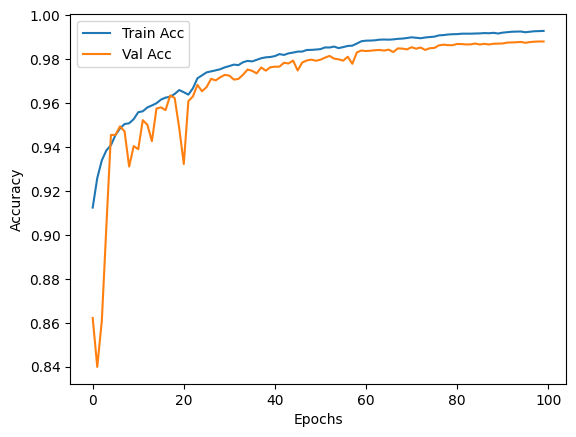

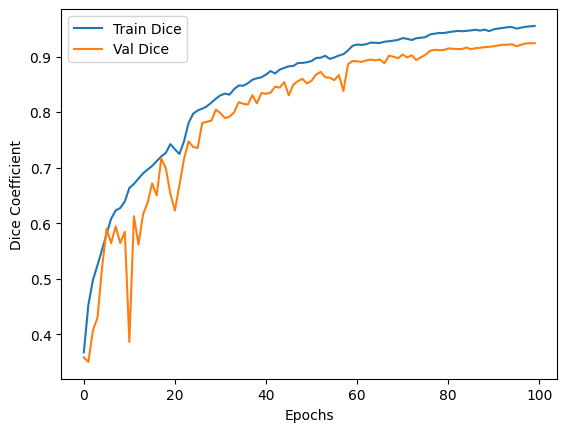

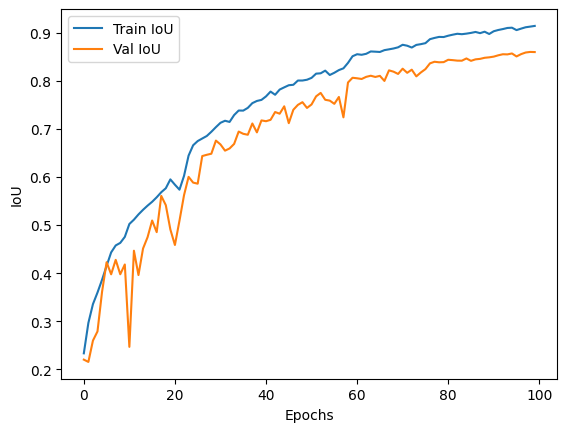

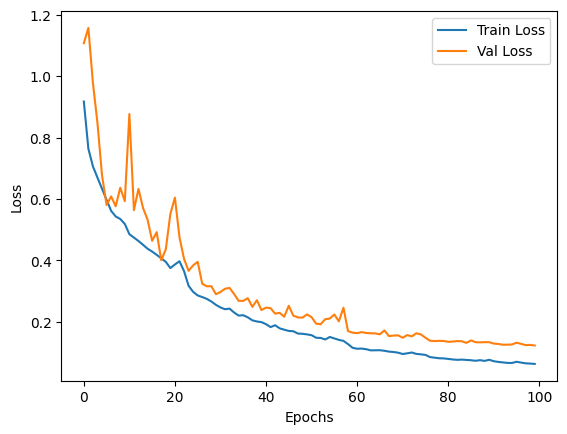

In [18]:
# Accuracy curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Dice curve
plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Val Dice')
plt.xlabel("Epochs")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.show()

# IoU curve  (FIXED key)
plt.plot(history.history['iou'], label='Train IoU')
plt.plot(history.history['val_iou'], label='Val IoU')
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend()
plt.show()

# Loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
loss, dice, iou, acc = model.evaluate(X_val, y_val, verbose=0)

print(f"Overall Results -> Dice: {dice:.4f}, IoU: {iou:.4f}, Accuracy: {acc:.4f}")

Overall Results -> Dice: 0.9277, IoU: 0.8658, Accuracy: 0.9881


In [20]:
def evaluate_subset(images, masks, name):
    loss, dice, iou, acc = model.evaluate(images, masks, verbose=0)
    print(f"{name} -> Dice: {dice:.4f}, IoU: {iou:.4f}, Accuracy: {acc:.4f}")

# Malignant
evaluate_subset(malignant_imgs, malignant_masks, "Malignant")

# Benign
evaluate_subset(benign_imgs, benign_masks, "Benign")

# Optional Overall
loss, dice, iou, acc = model.evaluate(X_val, y_val, verbose=0)

print(f"Overall Results -> Dice: {dice:.4f}, IoU: {iou:.4f}, Accuracy: {acc:.4f}")


Malignant -> Dice: 0.9514, IoU: 0.9074, Accuracy: 0.9853
Benign -> Dice: 0.9525, IoU: 0.9095, Accuracy: 0.9936
Overall Results -> Dice: 0.9277, IoU: 0.8658, Accuracy: 0.9881


In [21]:
print(model.metrics_names)

['loss', 'compile_metrics']


In [22]:
# Malignant
evaluate_subset(malignant_imgs, malignant_masks, "Malignant")

# Benign
evaluate_subset(benign_imgs, benign_masks, "Benign")

# Normal
evaluate_subset(norm_imgs, norm_masks, "Normal")

Malignant -> Dice: 0.9514, IoU: 0.9074, Accuracy: 0.9853
Benign -> Dice: 0.9525, IoU: 0.9095, Accuracy: 0.9936
Normal -> Dice: 0.0316, IoU: 0.0316, Accuracy: 0.9996


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


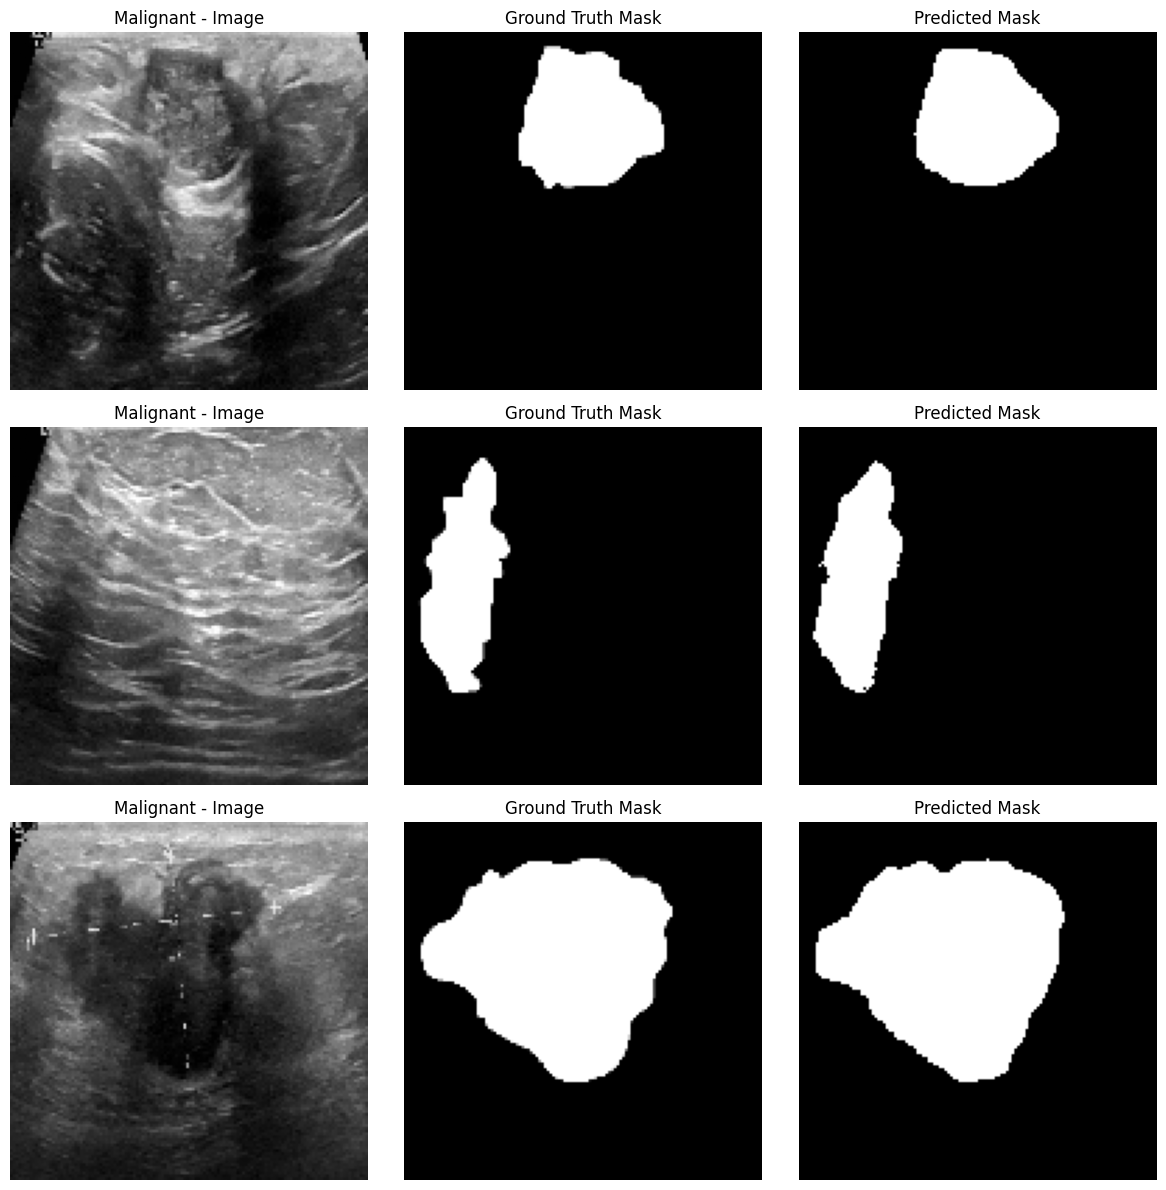

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


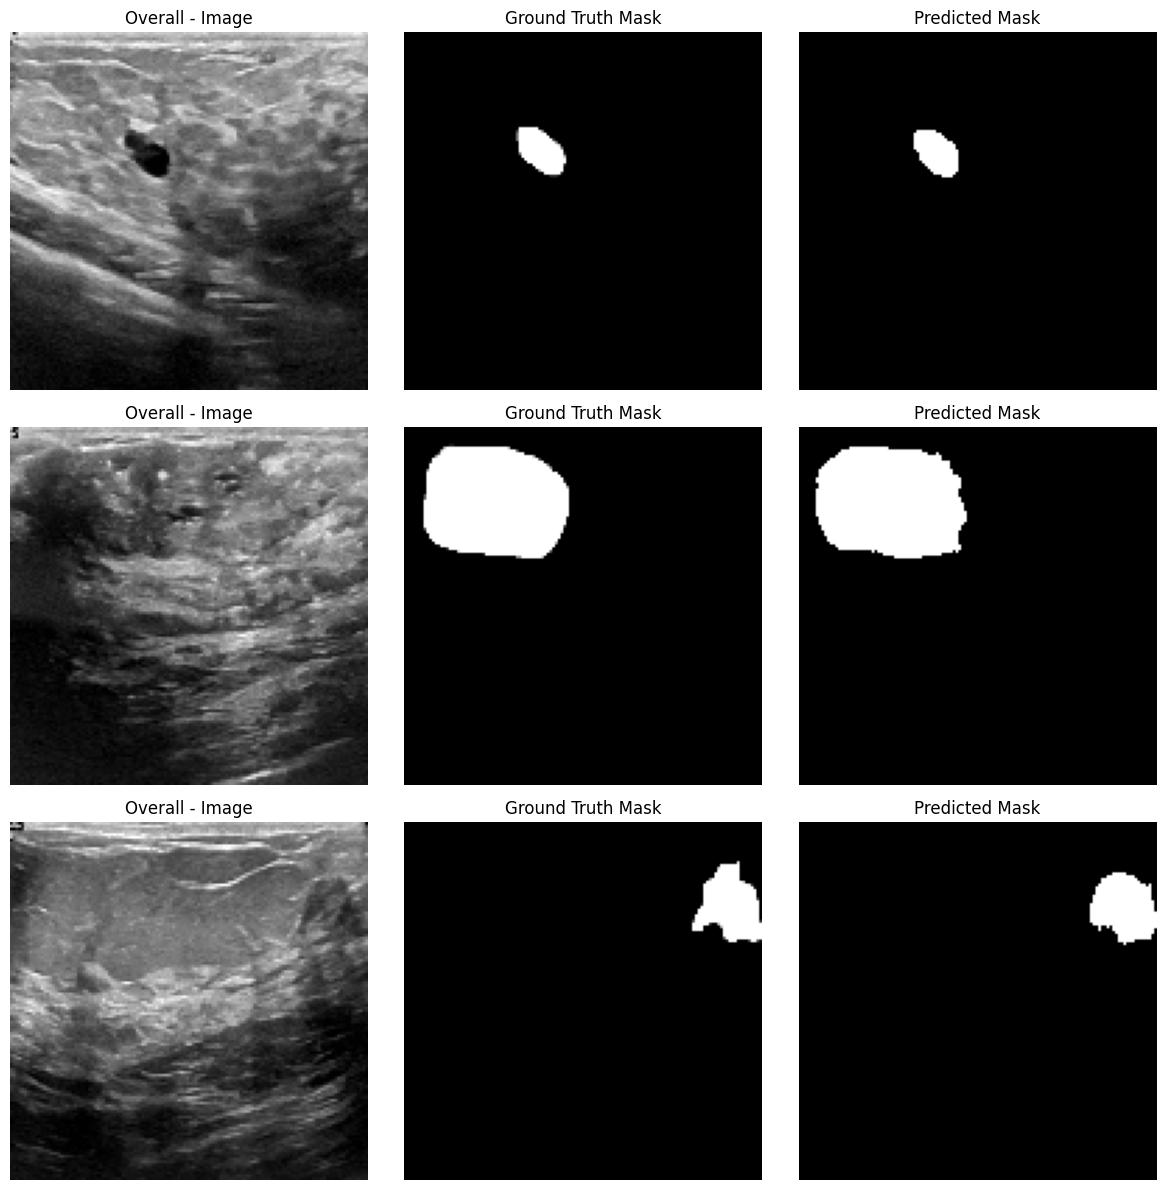

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


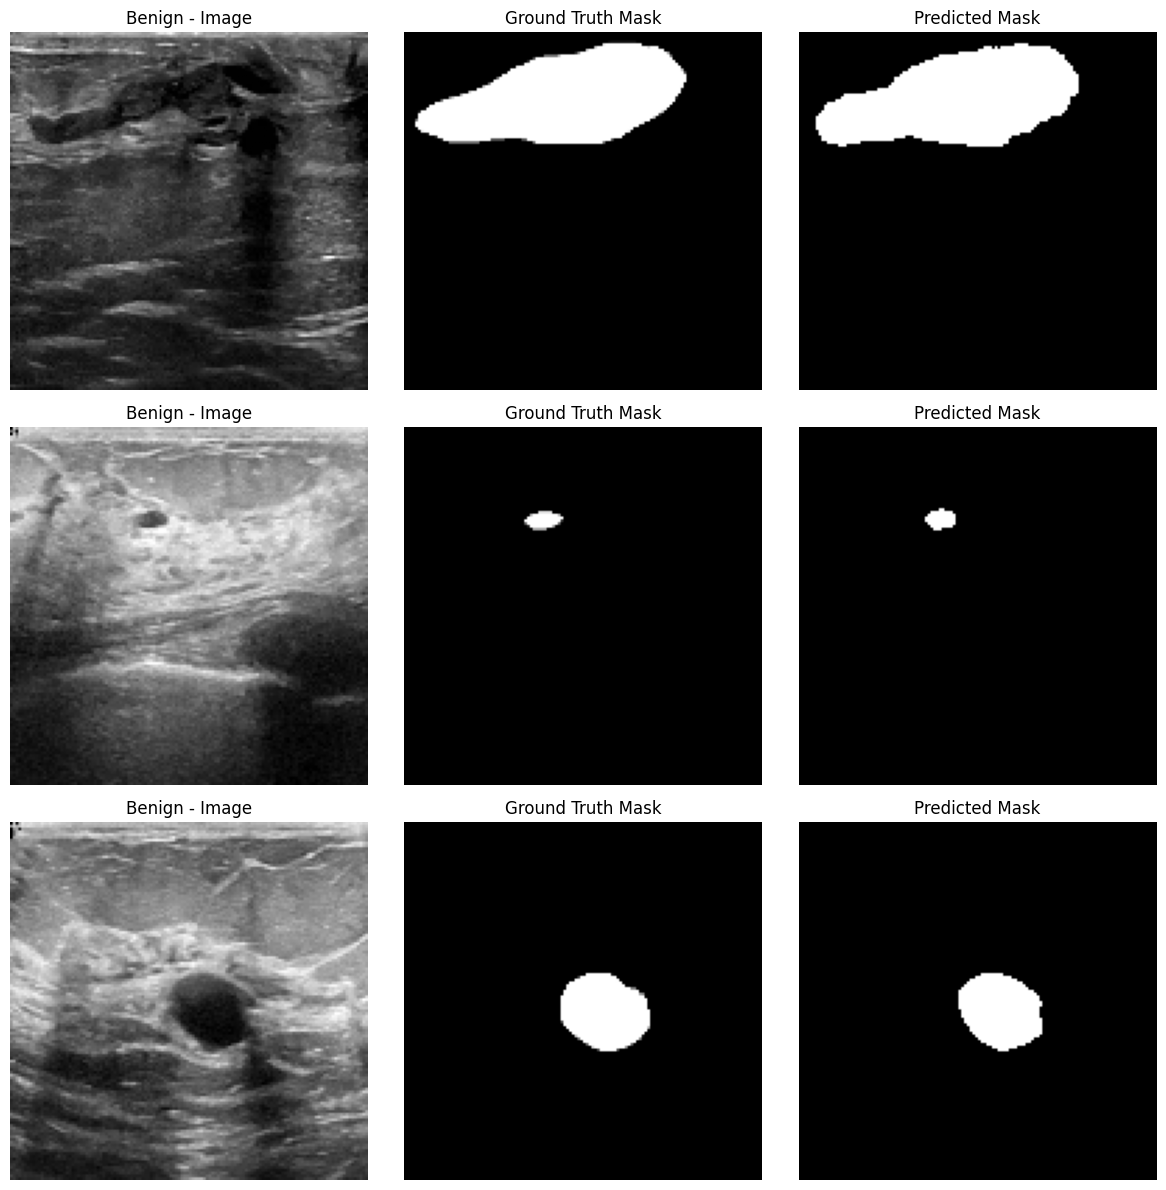

In [23]:
import random

def visualize_predictions(images, masks, name, num_samples=3):
    """Show random samples of predicted vs ground truth masks"""
    indices = random.sample(range(len(images)), num_samples)

    plt.figure(figsize=(12, num_samples * 4))
    for i, idx in enumerate(indices):
        img = images[idx]
        true_mask = masks[idx]

        # Model prediction
        pred_mask = model.predict(img[np.newaxis, ...])[0]
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        # Show input image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"{name} - Image")
        plt.axis('off')

        # Show ground truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')

        # Show predicted mask
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize for each class
visualize_predictions(malignant_imgs, malignant_masks, "Malignant")
visualize_predictions(full_imgs, full_masks, "Overall")
visualize_predictions(benign_imgs, benign_masks, "Benign")